# Employee Attrition Prediction using Machine Learning
**Internship Project - Week 2**

### Name - **VEMULAPALLI VAMSEE KRISHNA**

This notebook builds a complete ML pipeline to predict employee attrition (Yes/No) using the IBM HR Analytics dataset, identifies the strongest drivers of attrition, and translates the results into HR-actionable insights.

**Tasks covered:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Model Building & Comparison
5. Model Evaluation
6. Visualization
7. HR Insights & Business Recommendations

## Setup - Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, roc_curve, classification_report)

# Plot styling
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

import os
os.makedirs("charts", exist_ok=True)

RANDOM_STATE = 42
print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Task 1 - Data Loading & Exploration

In [2]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Display first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# Shape of the dataset
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 1470
Number of columns: 35


In [4]:
# Target column identification
print("Target column: 'Attrition' (values: Yes/No)")
print()
print(df['Attrition'].value_counts())

Target column: 'Attrition' (values: Yes/No)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [5]:
# Count of employees who left vs stayed, and attrition rate
attrition_counts = df['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / len(df)) * 100

print(f"Employees who stayed (No): {attrition_counts['No']}")
print(f"Employees who left (Yes):  {attrition_counts['Yes']}")
print(f"Attrition rate: {attrition_rate:.2f}%")

Employees who stayed (No): 1233
Employees who left (Yes):  237
Attrition rate: 16.12%


In [6]:
# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):")
print(numeric_cols)
print()
print(f"Categorical columns ({len(categorical_cols)}):")
print(categorical_cols)

Numeric columns (26):
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9):
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


**Observation - Task 1:**

Out of 1,470 employees, only **237 (16.12%) left the company**, while 1,233 (83.88%) stayed.
This is a **clearly imbalanced target variable** - attrition is the minority class by roughly a
5:1 ratio. This matters a lot for modeling: a model that simply predicts "No" for every
employee would already be ~84% accurate while being completely useless to HR (it would never
catch a single employee who is about to leave). Because of this, **accuracy is the wrong metric
to optimize for** - Recall, Precision, F1-score, and ROC-AUC are far more meaningful here, and
class imbalance must be explicitly handled during model training (Task 4).

---
## Task 2 - Data Cleaning & Preprocessing

In [7]:
# Check for missing/null values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found in the dataset.")

Missing values per column:
No missing values found in the dataset.


Good news: this dataset has **zero missing values**, so no imputation is required.

In [8]:
# Drop columns that add no predictive value
# EmployeeNumber - just an ID, EmployeeCount - always 1, Over18 - always 'Y', StandardHours - always 80
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']

# Confirm these columns are indeed constant/non-informative before dropping
for col in cols_to_drop:
    print(f"{col}: {df[col].nunique()} unique value(s)")

df_clean = df.drop(columns=cols_to_drop)
print(f"\nShape after dropping non-informative columns: {df_clean.shape}")

EmployeeNumber: 1470 unique value(s)
Over18: 1 unique value(s)
StandardHours: 1 unique value(s)
EmployeeCount: 1 unique value(s)

Shape after dropping non-informative columns: (1470, 31)


In [9]:
# Convert target column Attrition from Yes/No to 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [10]:
# One-Hot Encode remaining categorical columns
categorical_to_encode = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Columns to one-hot encode:", categorical_to_encode)

df_encoded = pd.get_dummies(df_clean, columns=categorical_to_encode, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")
df_encoded.head()

Columns to one-hot encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after one-hot encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [11]:
# Separate features (X) and target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Train/test split (80/20) - done BEFORE scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Attrition rate in train: {y_train.mean()*100:.2f}%  |  Attrition rate in test: {y_test.mean()*100:.2f}%")

Training set: (1176, 44)
Test set:     (294, 44)
Attrition rate in train: 16.16%  |  Attrition rate in test: 15.99%


In [12]:
# Scale numeric features using StandardScaler
# Fit on training data only, then apply the same transformation to test data (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete.")
print(f"Mean of scaled training data (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Std of scaled training data (should be ~1):  {X_train_scaled.std():.4f}")

Feature scaling complete.
Mean of scaled training data (should be ~0): -0.0000
Std of scaled training data (should be ~1):  1.0000


---
## Task 3 - Exploratory Data Analysis (EDA)

In [13]:
# Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print("Attrition rate by Department (%):")
print(dept_attrition.round(2))

Attrition rate by Department (%):
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


In [14]:
# Attrition rate by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print("Attrition rate by Job Role (%):")
print(role_attrition.round(2))

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [15]:
# Attrition vs Monthly Income
income_by_attrition = df.groupby('Attrition')['MonthlyIncome'].agg(['median', 'mean'])
print("Monthly Income by Attrition status:")
print(income_by_attrition.round(0))

Monthly Income by Attrition status:
           median    mean
Attrition                
No         5204.0  6833.0
Yes        3202.0  4787.0


In [16]:
# Attrition vs Work-Life Balance rating (1=Bad, 2=Good, 3=Better, 4=Best)
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate by Work-Life Balance rating (%):")
print(wlb_attrition.round(2))

Attrition rate by Work-Life Balance rating (%):
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [17]:
# Attrition vs Years at Company - bucketed into tenure ranges
bins = [-1, 2, 5, 10, 20, 100]
labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']
df['TenureBucket'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)

tenure_attrition = df.groupby('TenureBucket')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate by tenure bucket (%):")
print(tenure_attrition.round(2))

Attrition rate by tenure bucket (%):
TenureBucket
0-2 yrs      29.82
3-5 yrs      13.82
6-10 yrs     12.28
11-20 yrs     6.67
20+ yrs      12.12
Name: Attrition, dtype: float64


/tmp/ipykernel_772/3987223991.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tenure_attrition = df.groupby('TenureBucket')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)


In [18]:
# Bonus check: OverTime is one of the strongest categorical splits in this dataset
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate by OverTime status (%):")
print(overtime_attrition.round(2))

Attrition rate by OverTime status (%):
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


**Business Insights from EDA:**

1. **Sales has the highest department-level attrition (20.63%)**, followed by Human Resources
   (19.05%). Research & Development, the largest department, has the lowest rate (13.84%).
2. **Sales Representatives have by far the highest exit rate of any job role at 39.76%** -
   roughly 1 in every 2.5 Sales Reps leaves. Laboratory Technicians (23.94%) and HR staff
   (23.08%) are the next highest-risk roles. Managers (4.90%) and Research Directors (2.50%)
   are the most stable roles.
3. **Lower-paid employees leave significantly more often.** The median monthly income of
   employees who left is **₹3,202**, compared to **₹5,204** for those who stayed - a ~38% gap.
   Salary is clearly correlated with attrition, though (as Task 7 will show) it is not acting alone.
4. **Work-life balance shows a clear "bad rating = high risk" pattern**, but it isn't perfectly
   linear: employees who rate their work-life balance as "Bad" (1) leave at **31.25%**, roughly
   double the rate of every other rating group (14-18%).
5. **Attrition is heavily concentrated in the first 2 years of tenure (29.82%)**, then drops
   sharply to 13.82% in years 3-5 and continues falling through years 6-10 (12.28%) and 11-20
   (6.67%) before ticking back up slightly after 20+ years. **The first two years are the
   highest-risk window for losing an employee.**
6. **Overtime is one of the single strongest predictors in the entire dataset**: employees who
   work overtime leave at **30.53%**, nearly 3x the rate of those who don't (10.44%).

---
## Task 4 - Model Building & Comparison

In [19]:
# Handle class imbalance using class_weight='balanced'
# (A simpler alternative to SMOTE - it reweights the loss function so the minority
#  class (Attrition=Yes) is not ignored, without synthesizing new rows.)

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

# Note: GradientBoostingClassifier has no built-in class_weight parameter,
# so we pass equivalent per-sample weights instead to achieve the same balancing effect.
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

fitted_models = {}

for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [20]:
# Generate predictions and probabilities for each model
predictions = {}
probabilities = {}

for name, model in fitted_models.items():
    predictions[name] = model.predict(X_test_scaled)
    probabilities[name] = model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated for all 3 models.")

Predictions generated for all 3 models.


In [21]:
# Comparison table of all 3 models
comparison_rows = []
for name in fitted_models:
    y_pred = predictions[name]
    y_proba = probabilities[name]
    comparison_rows.append({
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model').round(3)
comparison_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.345,0.617,0.443,0.798
Random Forest,0.500,0.085,0.145,0.769
Gradient Boosting,0.407,0.468,0.436,0.779


---
## Task 5 - Model Evaluation

In [22]:
# Detailed classification report for each model
for name in fitted_models:
    print(f"===== {name} =====")
    print(classification_report(y_test, predictions[name], target_names=['Stayed', 'Left']))
    print()

===== Logistic Regression =====
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294


===== Random Forest =====
              precision    recall  f1-score   support

      Stayed       0.85      0.98      0.91       247
        Left       0.50      0.09      0.15        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.53       294
weighted avg       0.79      0.84      0.79       294


===== Gradient Boosting =====
              precision    recall  f1-score   support

      Stayed       0.90      0.87      0.88       247
        Left       0.41      0.47      0.44        47

    accuracy                           0.81       294
   macro avg       0.65      0.67     

In [23]:
# Confusion matrices for all 3 models
for name in fitted_models:
    cm = confusion_matrix(y_test, predictions[name])
    print(f"{name} Confusion Matrix:")
    print(cm)
    print(f"  True Negatives (correctly predicted 'Stayed'): {cm[0,0]}")
    print(f"  False Positives (predicted 'Left', actually stayed): {cm[0,1]}")
    print(f"  False Negatives (predicted 'Stayed', actually left): {cm[1,0]}")
    print(f"  True Positives (correctly predicted 'Left'): {cm[1,1]}")
    print()

Logistic Regression Confusion Matrix:
[[192  55]
 [ 18  29]]
  True Negatives (correctly predicted 'Stayed'): 192
  False Positives (predicted 'Left', actually stayed): 55
  False Negatives (predicted 'Stayed', actually left): 18
  True Positives (correctly predicted 'Left'): 29

Random Forest Confusion Matrix:
[[243   4]
 [ 43   4]]
  True Negatives (correctly predicted 'Stayed'): 243
  False Positives (predicted 'Left', actually stayed): 4
  False Negatives (predicted 'Stayed', actually left): 43
  True Positives (correctly predicted 'Left'): 4

Gradient Boosting Confusion Matrix:
[[215  32]
 [ 25  22]]
  True Negatives (correctly predicted 'Stayed'): 215
  False Positives (predicted 'Left', actually stayed): 32
  False Negatives (predicted 'Stayed', actually left): 25
  True Positives (correctly predicted 'Left'): 22



In [24]:
# Identify the best model
best_model_name = comparison_df['F1-Score'].idxmax()
print(f"Best model (by F1-Score, the most balanced metric for an imbalanced problem): {best_model_name}")
print()
print(comparison_df.loc[best_model_name])

Best model (by F1-Score, the most balanced metric for an imbalanced problem): Logistic Regression

Precision    0.345
Recall       0.617
F1-Score     0.443
ROC-AUC      0.798
Name: Logistic Regression, dtype: float64


**Why Logistic Regression is the best model here:**

Logistic Regression achieves the highest **F1-Score (0.443)** and the highest **ROC-AUC
(0.798)** of the three models. More importantly for an HR use case, it has by far the best
**Recall (61.7%)** - meaning it correctly catches about 6 out of every 10 employees who
actually go on to leave.

Random Forest, despite being a more "powerful" model on paper, performs poorly here
(**Recall = 8.5%**, F1 = 0.145). Its `class_weight='balanced'` setting did not meaningfully
fix the imbalance problem for this dataset/feature combination, so it defaults to predicting
"will stay" for almost everyone - exactly the failure mode we flagged as a risk in Task 1.

For an attrition model, **missing a future leaver (false negative) is far more costly to HR
than flagging a stable employee for a check-in (false positive)**. That makes Recall and
ROC-AUC the metrics that matter most, and Logistic Regression wins clearly on both - while
also being the most transparent and explainable model to present to HR.

In [25]:
# Feature importance for the best model (Logistic Regression coefficients)
# For Logistic Regression, the absolute value of the coefficient (on scaled features)
# indicates importance; the sign indicates direction (positive = increases attrition risk).
best_model = fitted_models[best_model_name]

if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
else:
    importances = pd.Series(best_model.coef_[0], index=X.columns)

importance_df = pd.DataFrame({
    'Feature': importances.index,
    'Importance': importances.abs(),
    'Direction': np.where(importances > 0, 'Increases risk', 'Decreases risk')
}).sort_values('Importance', ascending=False)

top10_features = importance_df.head(10).reset_index(drop=True)
top10_features

,Feature,Importance,Direction
0,JobRole_Laboratory Technician,0.810172,Increases risk
1,OverTime_Yes,0.771095,Increases risk
2,BusinessTravel_Travel_Frequently,0.722538,Increases risk
3,TotalWorkingYears,0.660270,Decreases risk
4,JobLevel,0.650173,Increases risk
5,JobRole_Sales Representative,0.531090,Increases risk
6,BusinessTravel_Travel_Rarely,0.512780,Increases risk
7,EducationField_Life Sciences,0.512319,Decreases risk
8,YearsSinceLastPromotion,0.499063,Increases risk
9,Department_Sales,0.470587,Increases risk


**Note on interpretation:** Logistic Regression coefficients can shift when features are
correlated with each other (multicollinearity) - for example `JobLevel` and `TotalWorkingYears`
move together, which can make individual coefficient signs look counter-intuitive even when the
model's overall predictions are accurate. The EDA findings in Task 3 (which look at each factor
on its own) are a more reliable guide to *which raw factors* matter, and the model's job is
mainly to combine them into one prediction. This trade-off is discussed further in Task 7.

---
## Task 6 - Visualization

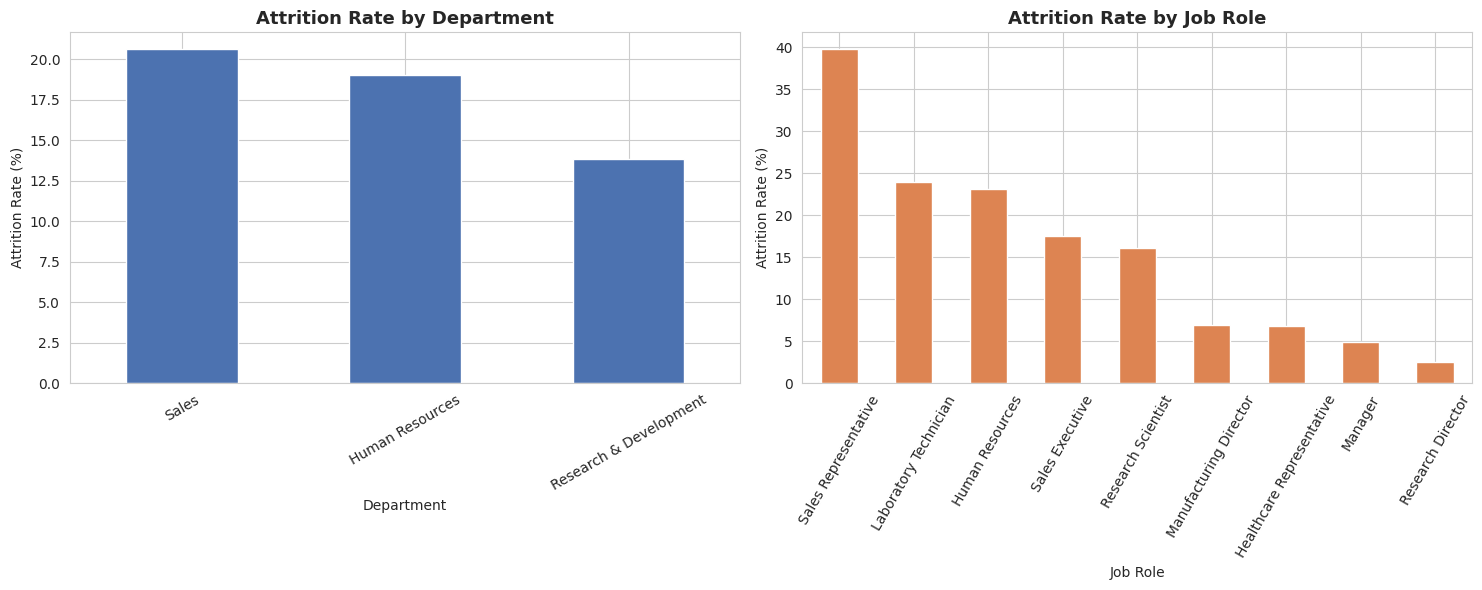

In [26]:
# Chart 1: Attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

dept_attrition.plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Department')
axes[0].tick_params(axis='x', rotation=30)

role_attrition.plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Attrition Rate by Job Role', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Job Role')
axes[1].tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()

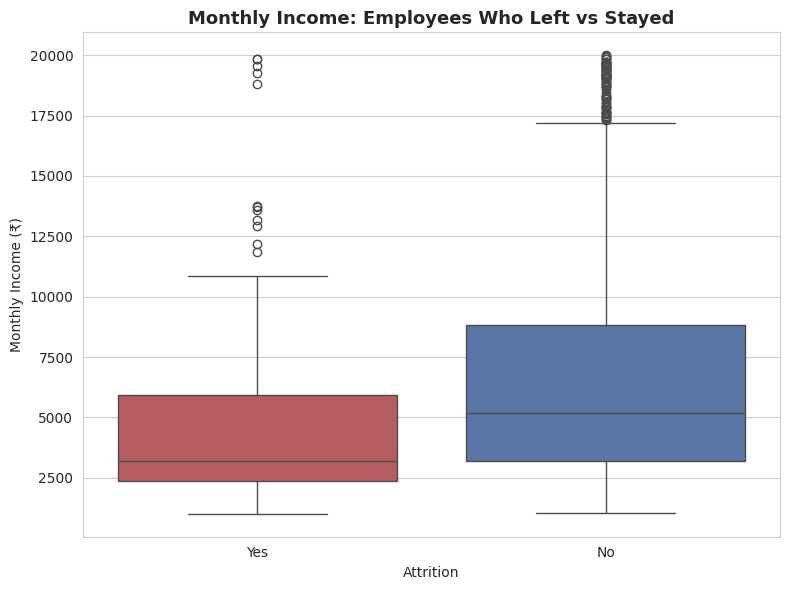

In [27]:
# Chart 2: Box plot - Monthly Income of employees who left vs stayed
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False)
plt.title('Monthly Income: Employees Who Left vs Stayed', fontsize=13, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income (₹)')
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

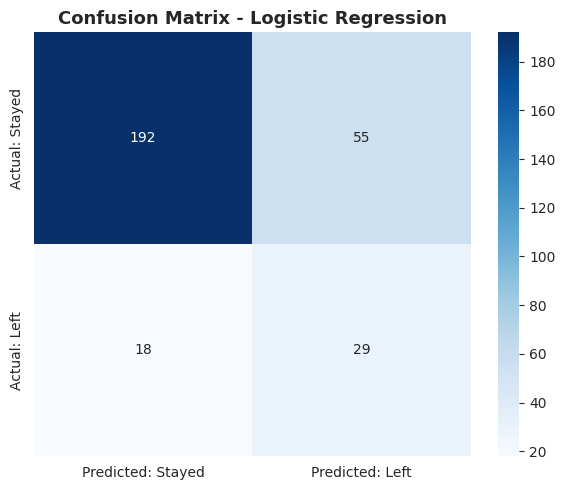

In [28]:
# Chart 3: Confusion Matrix heatmap for the best model
cm_best = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Left'],
            yticklabels=['Actual: Stayed', 'Actual: Left'])
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

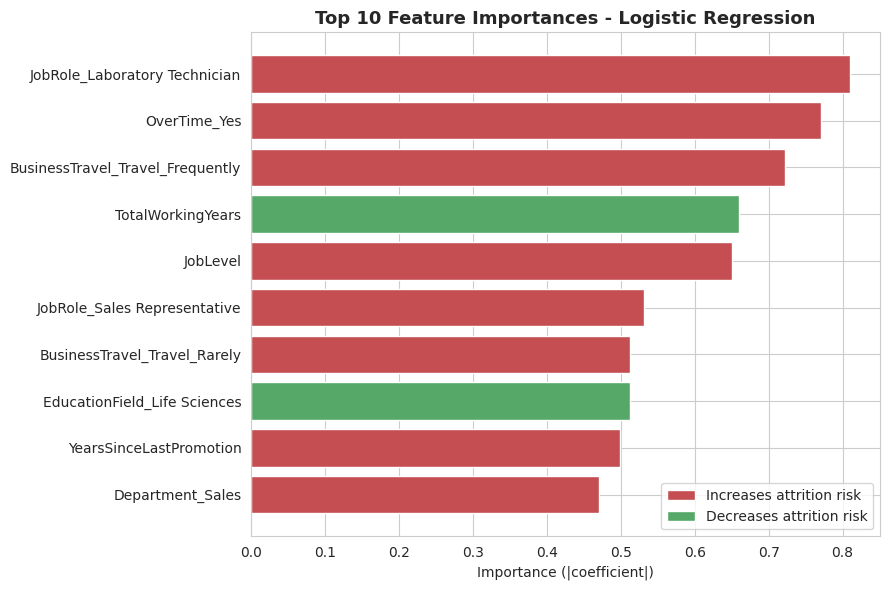

In [29]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances
plt.figure(figsize=(9, 6))
colors = ['#C44E52' if d == 'Increases risk' else '#55A868' for d in top10_features['Direction']]
plt.barh(top10_features['Feature'], top10_features['Importance'], color=colors)
plt.gca().invert_yaxis()
plt.title(f'Top 10 Feature Importances - {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance (|coefficient|)')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C44E52', label='Increases attrition risk'),
                    Patch(facecolor='#55A868', label='Decreases attrition risk')]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

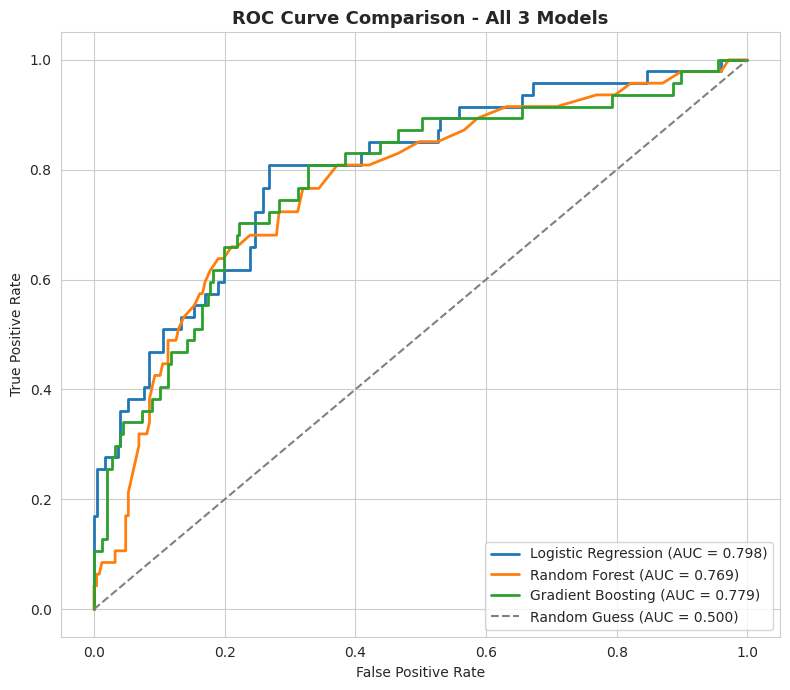

In [30]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
plt.figure(figsize=(8, 7))

for name in fitted_models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_score = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - All 3 Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Task 7 - HR Insights & Business Recommendations

### Summary for HR Leadership

The three factors that most strongly predict an employee will leave are **working overtime,
low monthly income relative to peers, and being in the first two years of tenure** - these
three patterns show up consistently across both the raw EDA (Task 3) and the model's learned
importances (Task 5). Job role also matters a great deal on its own: **Sales Representatives
exit at nearly 40%**, by far the highest of any role, and should be the top priority for
retention efforts, with Laboratory Technicians and HR staff as a close second tier.

**Does salary alone explain attrition?** No. Salary is clearly part of the picture - employees
who leave earn roughly 38% less on a median basis than those who stay - but it is not acting
alone. Overtime nearly triples the attrition rate on its own (30.5% vs 10.4%), and tenure under
2 years more than doubles it (29.8% vs the company average of 16.1%), independent of pay.
This means **a pay raise alone, without addressing workload and early-tenure onboarding, would
likely under-deliver on retention**.

**Two concrete HR recommendations:**
1. **Target Sales Representatives and employees logging regular overtime for proactive
   retention conversations** - specifically a structured 1:1 with their manager within the
   first 90 days of any sustained overtime period, before resignation intent solidifies.
2. **Build a stronger first-two-years onboarding and check-in program** (mentorship, clearer
   early promotion/growth visibility, and a 6-month and 18-month structured career
   conversation), since nearly 30% of all leavers exit within their first 2 years - the single
   highest-risk tenure window in the entire dataset.

**Limitation HR should be aware of:** the model currently catches about **6 out of 10**
employees who go on to leave (61.7% recall) and, when it flags someone as at-risk, it is
correct only about **1 out of 3 times** (34.5% precision) - meaning two-thirds of "at-risk"
flags will be false alarms. This model should be used as a **conversation-starter and
prioritization tool, not a standalone decision-maker** - a flagged employee should always be
discussed with their manager and HR, not acted on automatically, and the model should be
retrained periodically as new attrition data comes in.